# Oligo Model to Assess Sequencing Accuracy

## Preprocessing
- Run the following script to extract microsatellite sequences from paired-end fastq reads

```bash
#! /bin/bash
python /home/tcheng/software/RETrace2/scripts/fastq_paired_microsatellite_extractor.py \
    /datasets/s3/altos-lab-kzhang/tcheng/20240216_AVITI_Oligo_5homopolymer_FreeStyle_2ndRun/0_Raw_Data/sample_95M_trim/5homopolymer_R1_sampled_trimmed.fastq \
    /datasets/s3/altos-lab-kzhang/tcheng/20240216_AVITI_Oligo_5homopolymer_FreeStyle_2ndRun/0_Raw_Data/sample_95M_trim/5homopolymer_R2_sampled_trimmed.fastq \
    ./
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
path = "/datasets/s3/altos-lab-kzhang/tcheng/20240216_AVITI_Oligo_5homopolymer_FreeStyle_2ndRun/1_Read/5homopolymer_R1_sampled_trimmed_R1R2result.tsv"

In [3]:
result = pd.read_csv(path, sep='\t')
result.head()

,read_r1,read_r2,umi,lib,ms_r1,ms_r2
0,ACCTCTTAGATGGTTCGAACATATGAGACGAGCTAAGATTGTATCA...,ACCTCTTAGATGGTTCGAACATATGAGACGAGCTAAGATTGTATCA...,ACCTCTTAGATGGTTCGAAC,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
1,TTAAGCCGGTGAGTCCCCGAAGAGCACTAGCAGTGAGCCGAGATCG...,TAAGCCGGTGAGTCCCCGAAGAGCACTAGCAGTGAGCCGAGATCGT...,TTAAGCCGGTGAGTCCCCGA,AGAGCACTAG,AAAAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAAAA
2,TTGTTTGGCAGGCTAAGGGAAGAGCACTAGCAGTGAGCCGAGATCG...,TTGTTTGGCAGGCTAAGGGAAGAGCACTAGCAGTGAGCCGAGATCG...,TTGTTTGGCAGGCTAAGGGA,AGAGCACTAG,AAAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAAA
3,CTGGTTCAGTCCATCTAGTGATATGAGACGAGCTAAGATTGTATCA...,ACTGGTTCAGTCCATCTAGTGATATGAGACGAGCTAAGATTGTATC...,CTGGTTCAGTCCATCTAGTG,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
4,GGGTCGGGTGTGGGTCCACGATATGAGACGAGCTAAGATTGTATCA...,AGGGTCGGGTGTGGGTCCACGATATGAGACGAGCTAAGATTGTATC...,GGGTCGGGTGTGGGTCCACG,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAAAAAAA


In [4]:
result.shape

(95423719, 6)

In [5]:
# count how many R1 row MS with na
result['ms_r1'].isna().sum()/result.shape[0]

0.03649604140874031

In [6]:
# count how many R2 row MS with na
result['ms_r2'].isna().sum()/result.shape[0]

0.03836845847519316

In [7]:
# drop any row with NaN 
result_dropna = result.dropna()
result_dropna.head()

,read_r1,read_r2,umi,lib,ms_r1,ms_r2
0,ACCTCTTAGATGGTTCGAACATATGAGACGAGCTAAGATTGTATCA...,ACCTCTTAGATGGTTCGAACATATGAGACGAGCTAAGATTGTATCA...,ACCTCTTAGATGGTTCGAAC,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
1,TTAAGCCGGTGAGTCCCCGAAGAGCACTAGCAGTGAGCCGAGATCG...,TAAGCCGGTGAGTCCCCGAAGAGCACTAGCAGTGAGCCGAGATCGT...,TTAAGCCGGTGAGTCCCCGA,AGAGCACTAG,AAAAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAAAA
2,TTGTTTGGCAGGCTAAGGGAAGAGCACTAGCAGTGAGCCGAGATCG...,TTGTTTGGCAGGCTAAGGGAAGAGCACTAGCAGTGAGCCGAGATCG...,TTGTTTGGCAGGCTAAGGGA,AGAGCACTAG,AAAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAAA
3,CTGGTTCAGTCCATCTAGTGATATGAGACGAGCTAAGATTGTATCA...,ACTGGTTCAGTCCATCTAGTGATATGAGACGAGCTAAGATTGTATC...,CTGGTTCAGTCCATCTAGTG,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
4,GGGTCGGGTGTGGGTCCACGATATGAGACGAGCTAAGATTGTATCA...,AGGGTCGGGTGTGGGTCCACGATATGAGACGAGCTAAGATTGTATC...,GGGTCGGGTGTGGGTCCACG,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAAAAAAA


In [8]:
# overall read1 and read 2 match 
(result_dropna['ms_r1'] == result_dropna['ms_r2']).sum()/result_dropna.shape[0]

0.9714763529592012

## Add metadata, library name, subunit

In [9]:
# add library name from lib lindex
lib_to_name = {'CGCTCAGTTC': '15xA', 'TATCTGACCT':'20xA', 'ATATGAGACG':'30xA', 'GCGCGATGTT': '10xA', 'AGAGCACTAG': '25xA'}
result_dropna.loc[:,'lib_name'] = [lib_to_name[lib] for lib in result_dropna['lib']]

# add library subunit legnth
lib_to_subunit = {'CGCTCAGTTC': 1, 'TATCTGACCT':1, 'ATATGAGACG':1, 'GCGCGATGTT': 1, 'AGAGCACTAG': 1}
result_dropna.loc[:,'subunit_length'] = [lib_to_subunit[lib] for lib in result_dropna['lib']]

/tmp/ipykernel_328261/300304104.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_dropna.loc[:,'lib_name'] = [lib_to_name[lib] for lib in result_dropna['lib']]
/tmp/ipykernel_328261/300304104.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_dropna.loc[:,'subunit_length'] = [lib_to_subunit[lib] for lib in result_dropna['lib']]


In [10]:
result_dropna['lib_name'].value_counts()

lib_name
15xA    23565415
25xA    19062192
10xA    18806212
20xA    16311483
30xA    13704259
Name: count, dtype: int64

## Add n repeat difference (Read 1 - Read 2)

In [11]:
result_dropna['length_difference'] = result_dropna['ms_r1'].str.len() - result_dropna['ms_r2'].str.len()

/tmp/ipykernel_328261/3255942474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_dropna['length_difference'] = result_dropna['ms_r1'].str.len() - result_dropna['ms_r2'].str.len()


In [12]:
result_dropna['Nrepeat_difference'] = result_dropna['length_difference'] / result_dropna['subunit_length']

/tmp/ipykernel_328261/3125792511.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_dropna['Nrepeat_difference'] = result_dropna['length_difference'] / result_dropna['subunit_length']


## Random pick 20 rows to manual check

In [13]:
# random sample 20 rows, should set seed in future
result_sample20 = result_dropna.sample(n=20, random_state=1)
result_sample20

,read_r1,read_r2,umi,lib,ms_r1,ms_r2,lib_name,subunit_length,length_difference,Nrepeat_difference
61049589,AAGATCAATGGATTCGGGCGGCGCGATGTTGACAGTGCCTGGCACA...,AGATCAATGGATTCGGGCGGCGCGATGTTGACAGTGCCTGGCACAT...,AAGATCAATGGATTCGGGCG,GCGCGATGTT,AAAAAAAAAAA,AAAAAAAAAAA,10xA,1,0,0.0
11459843,GTTTGTCAGTGATTCAGTTAAGAGCACTAGCAGTGAGCCGAGATCG...,GTTTGTCAGTGATTCAGTTAAGAGCACTAGCAGTGAGCCGAGATCG...,GTTTGTCAGTGATTCAGTTA,AGAGCACTAG,AAAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAAA,25xA,1,0,0.0
36374120,CTGATGGCTGATCAGTTTTCAGAGCACTAGCAGTGAGCCGAGATCG...,CTGATGGCTGATCAGTTTTCAGAGCACTAGCAGTGAGCCGAGATCG...,CTGATGGCTGATCAGTTTTC,AGAGCACTAG,AAAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAAA,25xA,1,0,0.0
78720891,CTAGCTTTTGCGGCGTAGTTTATCTGACCTGATTGTGCCACTGCAC...,CTAGCTTTTGCGGCGTAGTTTATCTGACCTGATTGTGCCACTGCAC...,CTAGCTTTTGCGGCGTAGTT,TATCTGACCT,AAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAA,20xA,1,0,0.0
6497212,TAGATACGGGAAAGTCATTAAGAGCACTAGCAGTGAGCCGAGATCG...,ATAGATACGGGAAAGTCATTAAGAGCACTAGCAGTGAGCCGAGATC...,TAGATACGGGAAAGTCATTA,AGAGCACTAG,AAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAA,25xA,1,0,0.0
16383430,TGATAATTTTTTGTTGATCGAGAGCACTAGCAGTGAGCCGAGATCG...,ATGATAATTTTTTGTTGATCGAGAGCACTAGCAGTGAGCCGAGATC...,TGATAATTTTTTGTTGATCG,AGAGCACTAG,AAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAA,25xA,1,0,0.0
2117730,CCCTAAGCTGGCGCAAATTCCGCTCAGTTCGGGGTTCTGCTTTTCC...,CCCTAAGCTGGCGCAAATTCCGCTCAGTTCGGGGTTCTGCTTTTCC...,CCCTAAGCTGGCGCAAATTC,CGCTCAGTTC,AAAAAAAAAAAAAAA,AAAAAAAAAAAAAAA,15xA,1,0,0.0
89503087,GGAGTCGACTAGGGCAGATTGCGCGATGTTGACAGTGCCTGGCACA...,GGAGTCGACTAGGGCAGATTGCGCGATGTTGACAGTGCCTGGCACA...,GGAGTCGACTAGGGCAGATT,GCGCGATGTT,AAAAAAAAAA,AAAAAAAAAA,10xA,1,0,0.0
16561222,CGGCGTTACGTCCTACCATCCGCTCAGTTCGGGGTTCTGCTTTTCC...,CGGCGTTACGTCCTACCATCCGCTCAGTTCGGGGTTCTGCTTTTCC...,CGGCGTTACGTCCTACCATC,CGCTCAGTTC,AAAAAAAAAAAAAAA,AAAAAAAAAAAAAAA,15xA,1,0,0.0
47902316,TACTCGAATGTGTTGGCGGGAGAGCACTAGCAGTGAGCCGAGATCG...,ACTCGAATGTGTTGGCGGGAGAGCACTAGCAGTGAGCCGAGATCGT...,TACTCGAATGTGTTGGCGGG,AGAGCACTAG,AAAAAAAAAAAAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAAAAAAAAAAAA,25xA,1,0,0.0


In [14]:
print(result_sample20.iloc[0,0])
print(result_sample20.iloc[0,0],'\n')
print(result_sample20.iloc[1,0])
print(result_sample20.iloc[1,1],'\n')
print(result_sample20.iloc[2,0])
print(result_sample20.iloc[2,1],'\n')
print(result_sample20.iloc[3,0])
print(result_sample20.iloc[3,1],'\n')
print(result_sample20.iloc[4,0])
print(result_sample20.iloc[4,1][1:],'\n')
print(result_sample20.iloc[5,0])
print(result_sample20.iloc[5,1],'\n')
print(result_sample20.iloc[6,0])
print(result_sample20.iloc[6,1],'\n')
print(result_sample20.iloc[7,0])
print(result_sample20.iloc[7,1],'\n')
print(result_sample20.iloc[8,0])
print(result_sample20.iloc[8,1][6:],'\n')
print(result_sample20.iloc[9,0])
print(result_sample20.iloc[9,1][1:],'\n')

AAGATCAATGGATTCGGGCGGCGCGATGTTGACAGTGCCTGGCACATGGTATGTACTGAATAAATATTTGGTGACTGAGTTATCCCTGACCCACACTGCAGAAGGAAAAAAAAAAAGCGAACGTAATT
AAGATCAATGGATTCGGGCGGCGCGATGTTGACAGTGCCTGGCACATGGTATGTACTGAATAAATATTTGGTGACTGAGTTATCCCTGACCCACACTGCAGAAGGAAAAAAAAAAAGCGAACGTAATT 

GTTTGTCAGTGATTCAGTTAAGAGCACTAGCAGTGAGCCGAGATCGTGCCACTGCACTTCAGCCTGGGTGACAGAGCAAGACTCCATCTCAAAAAAAAAAAAAAAAAAAAAAAAATCAAGTCACTGAA
GTTTGTCAGTGATTCAGTTAAGAGCACTAGCAGTGAGCCGAGATCGTGCCACTGCACTTCAGCCTGGGTGACAGAGCAAGACTCCATCTCAAAAAAAAAAAAAAAAAAAAAAAAATCAAGTCACTGAA 

CTGATGGCTGATCAGTTTTCAGAGCACTAGCAGTGAGCCGAGATCGTGCCACTGCACTTCAGCCTGGGTGACAGAGCAAGACTCCATCTCAAAAAAAAAAAAAAAAAAAAAAAAATCAAGTCACTGAA
CTGATGGCTGATCAGTTTTCAGAGCACTAGCAGTGAGCCGAGATCGTGCCACTGCACTTCAGCCTGGGTGACAGAGCAAGACTCCATCTCAAAAAAAAAAAAAAAAAAAAAAAAATCAAGTCACTGAA 

CTAGCTTTTGCGGCGTAGTTTATCTGACCTGATTGTGCCACTGCACTCCAGCCTGGGTGACAGAGCAAGACCCTGTCTCAAAAAAAAAAAAAAAAAAAAGACAGGAACTTCCAAATACTGAGCTAAAT
CTAGCTTTTGCGGCGTAGTTTATCTGACCTGATTGTGCCACTGCACTCCAGCCTGGGTGACAGAGCAAGACCCTGTCTCAAAAAAAAAAAA

In [15]:
print(result_sample20.iloc[10,0])
print(result_sample20.iloc[10,1],'\n')
print(result_sample20.iloc[11,0])
print(result_sample20.iloc[11,1],'\n')
print(result_sample20.iloc[12,0])
print(result_sample20.iloc[12,1],'\n')
print(result_sample20.iloc[13,0])
print(result_sample20.iloc[13,1][1:],'\n')
print(result_sample20.iloc[14,0])
print(result_sample20.iloc[14,1],'\n')
print(result_sample20.iloc[15,0])
print(result_sample20.iloc[15,1],'\n')
print(result_sample20.iloc[16,0])
print(result_sample20.iloc[16,1],'\n')
print(result_sample20.iloc[17,0])
print(result_sample20.iloc[17,1],'\n')
print(result_sample20.iloc[18,0])
print(result_sample20.iloc[18,1][5:],'\n')
print(result_sample20.iloc[19,0])
print(result_sample20.iloc[19,1],'\n')

AATGGCGACCAGGTTAAATACGCTCAGTTCGGGGTTCTGCTTTTCCTATTTGTGTTGGCATTTGAAAGATTGTGGAGGCAGAAAACTTTCTGGAATGTCAAAAAAAAAAAAAAATGCTGGAACTCTTA
AATGGCGACCAGGTTAAATACGCTCAGTTCGGGGTTCTGCTTTTCCTATTTGTGTTGGCATTTGAAAGATTGTGGAGGCAGAAAACTTTCTGGAATGTCAAAAAAAAAAAAAAATGCTGGAACTCTTA 

TTAATGAGTTAAGACAGCGACGCTCAGTTCGGGGTTCTGCTTTTCCTATTTGTGTTGGCATTTGAAAGATTGTGGAGGCAGAAAACTTTCTGGAATGTCAAAAAAAAAAAAATGCTGGAACTCTTATT
AATTAATGAGTTAAGACAGCGACGCTCAGTTCGGGGTTCTGCTTTTCCTATTTGTGTTGGCATTTGAAAGATTGTGGAGGCAGAAAACTTTCTGGAATGTCAAAAAAAAAAAAATGCTGGAACTCTTA 

ATCGGGCTAGTATGTAGTTTATATGAGACGAGCTAAGATTGTATCACTGTACTCCAGCCTGGGCAACAGAGCAAGACTCTGTCTCAAAAAAAAAAAAAAAAAAGAAAAAAAAAAACTGCCAACGGGAC
ATCGGGCTAGTATGTAGTTTATATGAGACGAGCTAAGATTGTATCACTGTACTCCAGCCTGGGCAACAGAGCAAGACTCTGTCTCAAAAAAAAAAAAAAAAAAAAAAAAAAAAAACTGCCAACGGGAC 

AATCGTAAGGAGCTATAGTTAGAGCACTAGCAGTGAGCCGAGATCGTGCCACTGCACTTCAGCCTGGGTGACAGAGCAAGACTCCATCTCAAAAAAAAAAAAAAAAAAAAAATGCTGGAACTCTTATT
AAATCGTAAGGAGCTATAGTTAGAGCACTAGCAGTGAGCCGAGATCGTGCCACTGCACTTCAGCCTGGGTGACAGAGCAAGACTCCATCTC

In [16]:
# calcualte fraction with perfect match
sum(result_sample20['Nrepeat_difference'] == 0)/result_sample20.shape[0]

0.95

## Are there more Ns in read 2 vs read 1?

In [17]:
def calculate_N(seq):
    return seq.count('N')

result_dropna['r1_N_count'] = result_dropna['read_r1'].apply(calculate_N)
result_dropna['r2_N_count'] = result_dropna['read_r2'].apply(calculate_N)

/tmp/ipykernel_328261/4290986590.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_dropna['r1_N_count'] = result_dropna['read_r1'].apply(calculate_N)
/tmp/ipykernel_328261/4290986590.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_dropna['r2_N_count'] = result_dropna['read_r2'].apply(calculate_N)


In [18]:
# mean ocunt
mean_read1 = result_dropna['r1_N_count'].mean()
print(mean_read1)
mean_read2 = result_dropna['r2_N_count'].mean()
print(mean_read2)

0.003986645709540366
0.01201063174048479


In [19]:
# inlcude data from other runs
n_count_df = pd.DataFrame({'Run':['20231009\nNextSeq 2000', '20231129\nAVITI Adpet PCR+', '20240131\nAVITI freestyle', '20240216\nAVITI freestyle\n(2nd run)'],
                           'mean_r1_N_count':[0.031, 0.016, 0.503, 0.0039],
                           'mean_r2_N_count':[0.125, 0.049, 0.610, 0.0120]})
n_count_df

,Run,mean_r1_N_count,mean_r2_N_count
0,20231009\nNextSeq 2000,0.0310,0.125
1,20231129\nAVITI Adpet PCR+,0.0160,0.049
2,20240131\nAVITI freestyle,0.5030,0.610
3,20240216\nAVITI freestyle\n(2nd run),0.0039,0.012


/tmp/ipykernel_328261/1829638031.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="center")
/tmp/ipykernel_328261/1829638031.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="center")


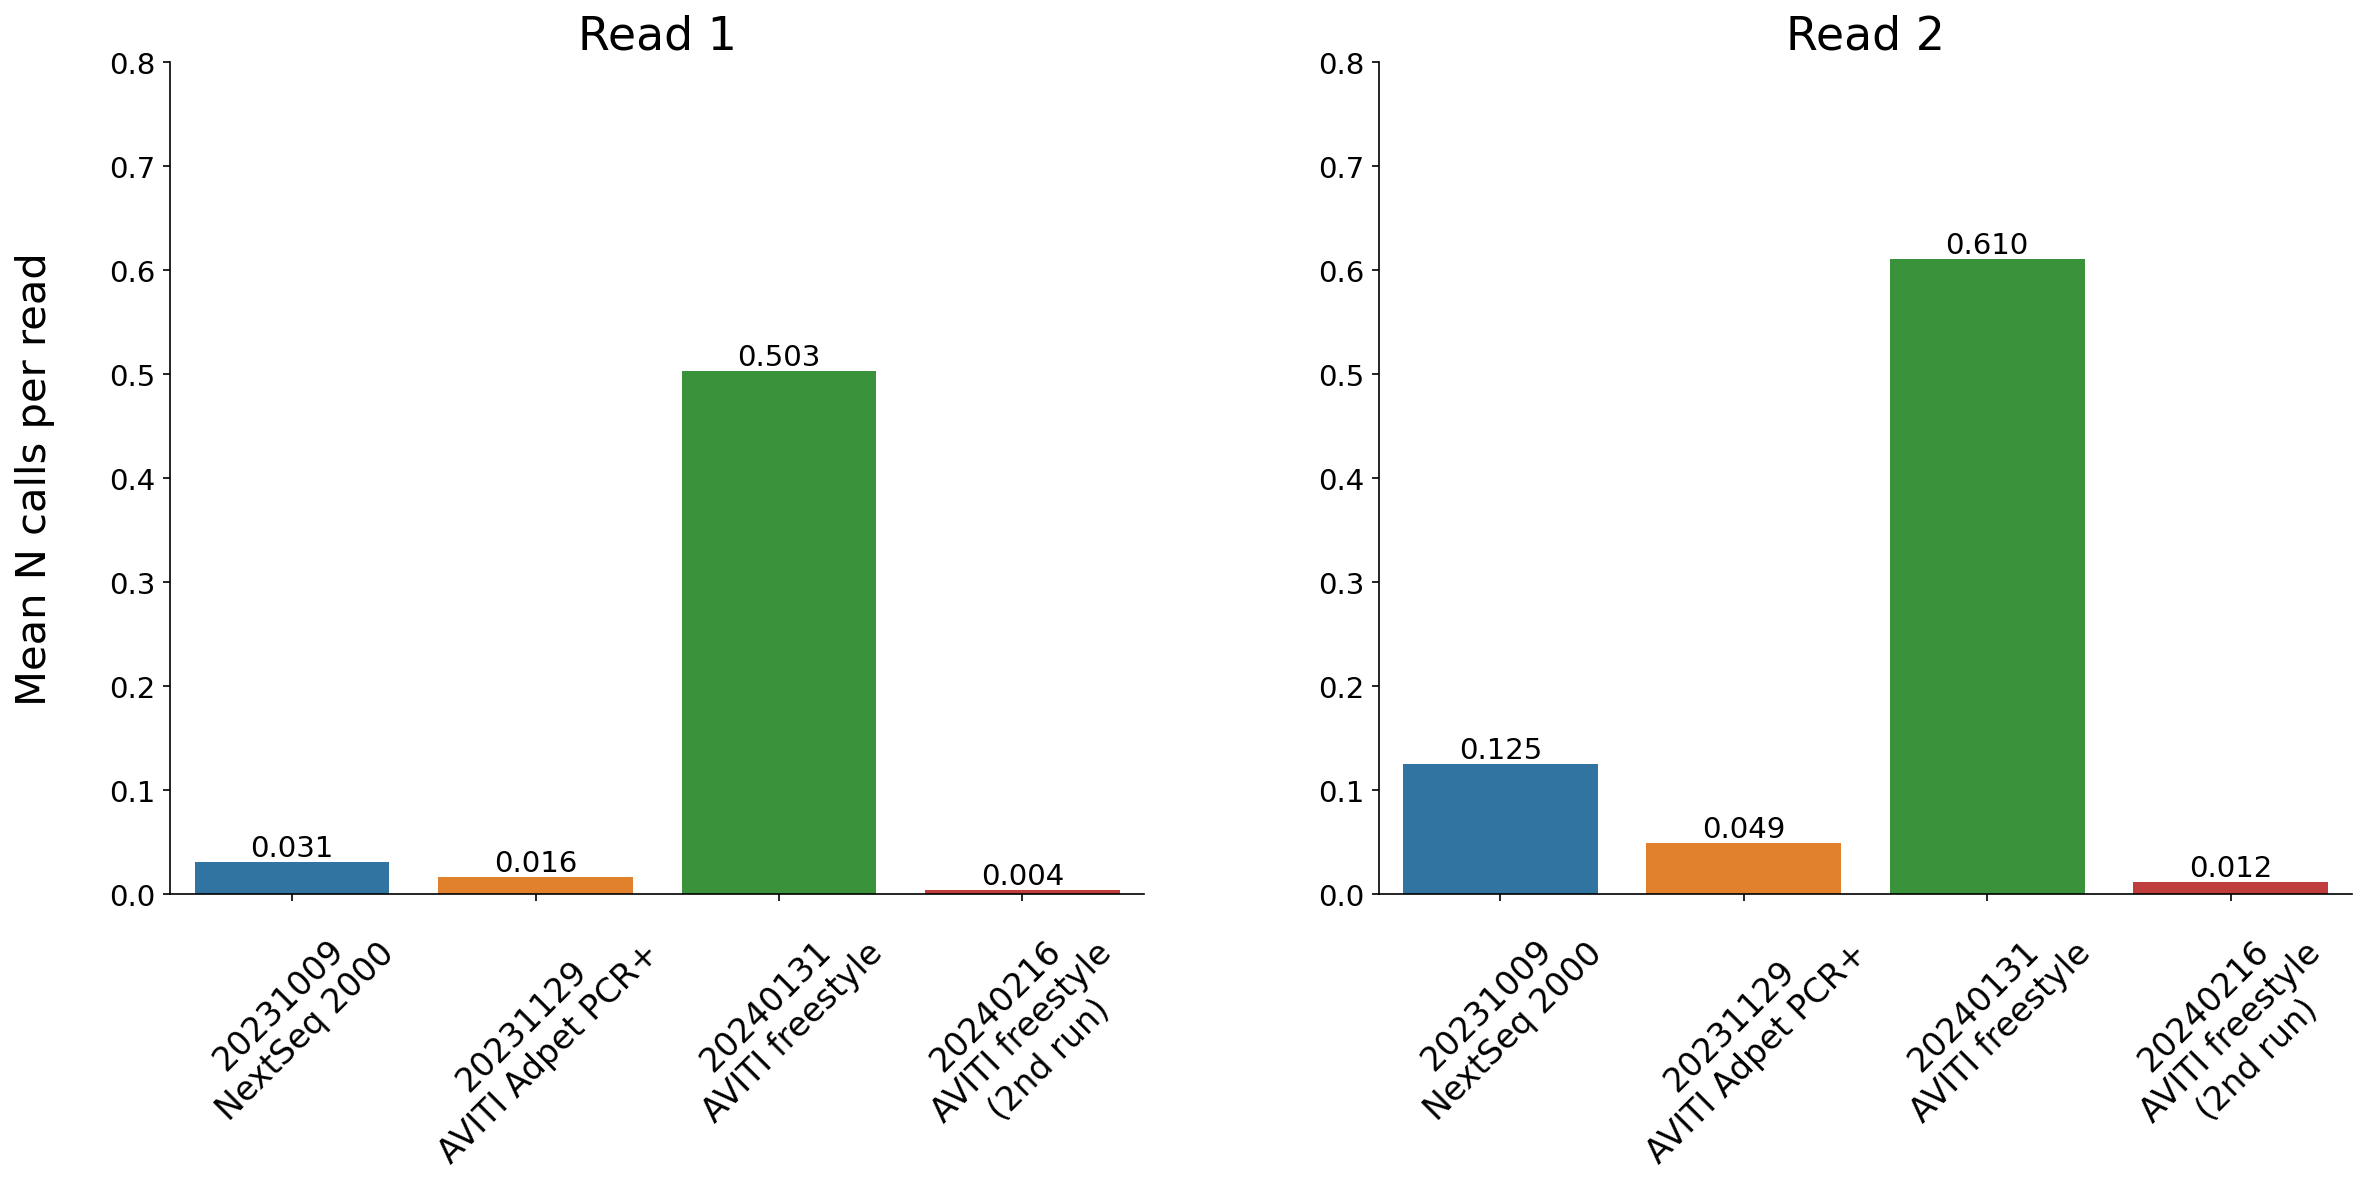

In [20]:
# Plot comparison with previous runs
fig, (ax1, ax2) = plt.subplots(figsize=(16, 8), dpi=150, ncols=2)
sns.barplot(x='Run', y='mean_r1_N_count', data=n_count_df, hue='Run', ax=ax1)
sns.barplot(x='Run', y='mean_r2_N_count', data=n_count_df, hue='Run', ax=ax2)

# Hide the right and top spines and adjust other elements
for ax in (ax1, ax2):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_ylim(0, 0.8)  # Assuming you want to set the y-axis limit from 0 to 1
    ax.set_xlabel('')

    # Rotate x-axis tick labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="center")

    # Adjust tick size
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=14)

ax1.set_title('Read 1', fontsize=22)
ax2.set_title('Read 2', fontsize=22)

ax1.set_ylabel('Mean N calls per read\n', fontsize=20)
ax2.set_ylabel(' \n\n\n', fontsize=14)

# Add text on top of the bars
for ax in (ax1, ax2):
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2., p.get_height(), '{0:.3f}'.format(p.get_height()), 
                fontsize=14, color='black', ha='center', va='bottom')

plt.tight_layout()  # Adjust layout
plt.show()


# Plot R1 R2 Match

In [21]:
# calculate percent of paired reads that match (n repeat difference = 0)
def zero_diff_percent(df):
    return (df['Nrepeat_difference'] == 0).sum() / df.shape[0] * 100

zero_diff_percent(result_dropna)

97.14763529592013

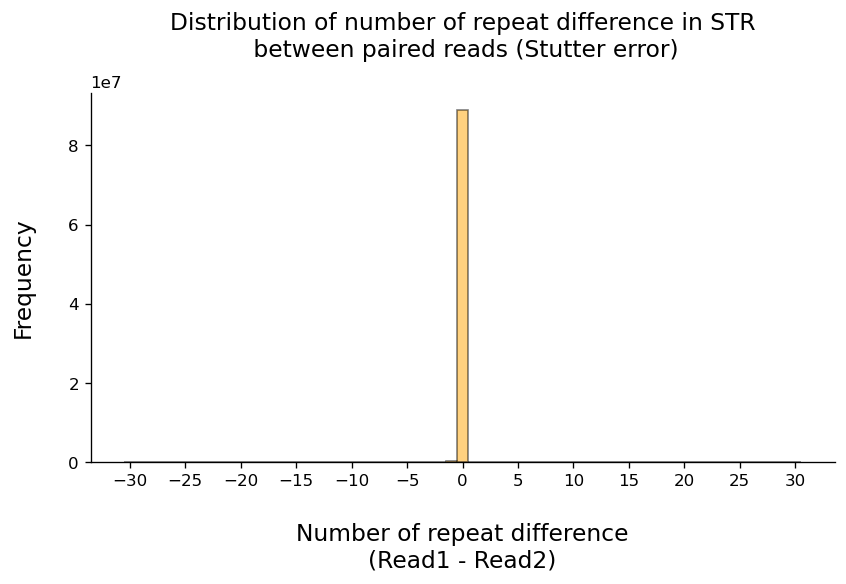

In [22]:
# Create a new figure and set its size
fig, ax = plt.subplots(figsize=(8,4), dpi=120) # you can adjust the size as you want

# Plot a histogram of the error rates (now in percentages)
ax.hist(result_dropna['Nrepeat_difference'], bins = np.arange(-30.5, 31.5, 1), alpha=0.5, color='orange', edgecolor='black')
ax.set_xlabel('\nNumber of repeat difference\n(Read1 - Read2)', fontsize=14)
ax.set_ylabel('Frequency\n', fontsize=14)
ax.set_title('Distribution of number of repeat difference in STR\n between paired reads (Stutter error)\n', fontsize=14)

# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xticks(range(-30, 31,5))  # to ensure x-axis ticks align with integer values

plt.show()

## Split by library (different Ms type)

/tmp/ipykernel_328261/2087542215.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='lib_name', y='Nrepeat_difference', data=result_dropna, order=['10xA', '15xA', '20xA', '25xA', '30xA'], scale='width') # set scale='width' to make violin fatter


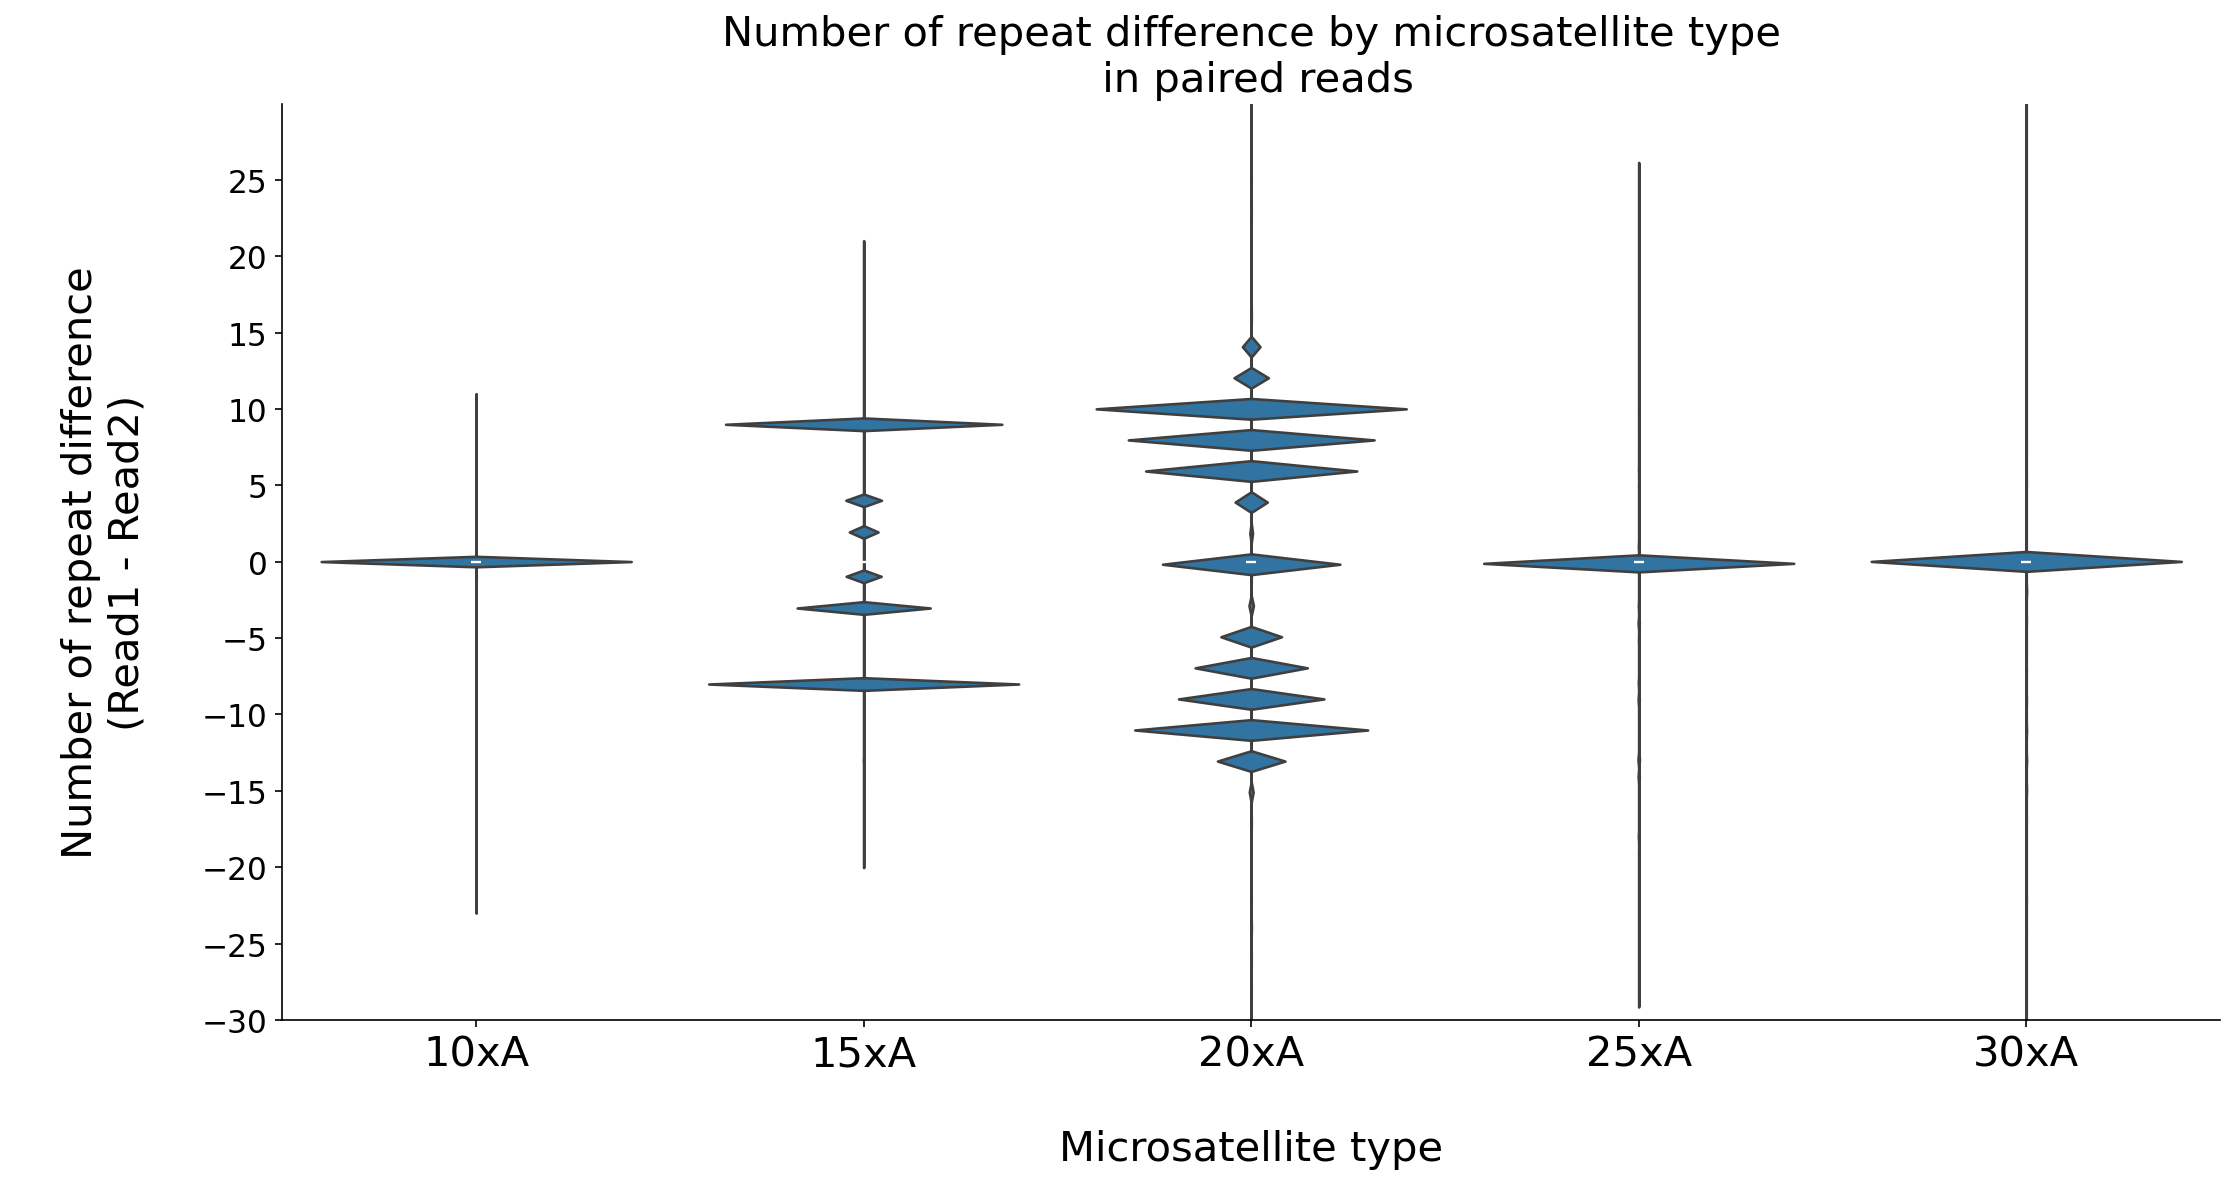

In [23]:
fig, ax = plt.subplots(figsize=(15,8), dpi=150)

sns.violinplot(x='lib_name', y='Nrepeat_difference', data=result_dropna, order=['10xA', '15xA', '20xA', '25xA', '30xA'], scale='width') # set scale='width' to make violin fatter

ax.set_title('Number of repeat difference by microsatellite type\n in paired reads', fontsize=20)
ax.set_xlabel("\nMicrosatellite type", fontsize=20)
ax.set_ylabel('\nNumber of repeat difference\n(Read1 - Read2)\n', fontsize=20)
ax.tick_params(axis='both', labelsize=15)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(-30,30)
ax.set_yticks(np.arange(-30,30,5))
ax.tick_params(axis='x', which='major', labelsize=20)

plt.tight_layout()
plt.show()

In [24]:
grouped_percent = result_dropna.groupby('lib_name').apply(zero_diff_percent)
grouped_percent = grouped_percent.reindex(['10xA', '15xA', '20xA', '25xA', '30xA'])

# Ensure the data is in the right format
grouped_percent = grouped_percent.reset_index()
grouped_percent = grouped_percent.rename(columns={0: 'zero_diff_percent'})
grouped_percent

/tmp/ipykernel_328261/3328979331.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_percent = result_dropna.groupby('lib_name').apply(zero_diff_percent)


,lib_name,zero_diff_percent
0,10xA,99.313264
1,15xA,98.794814
2,20xA,97.451268
3,25xA,95.099892
4,30xA,93.830276


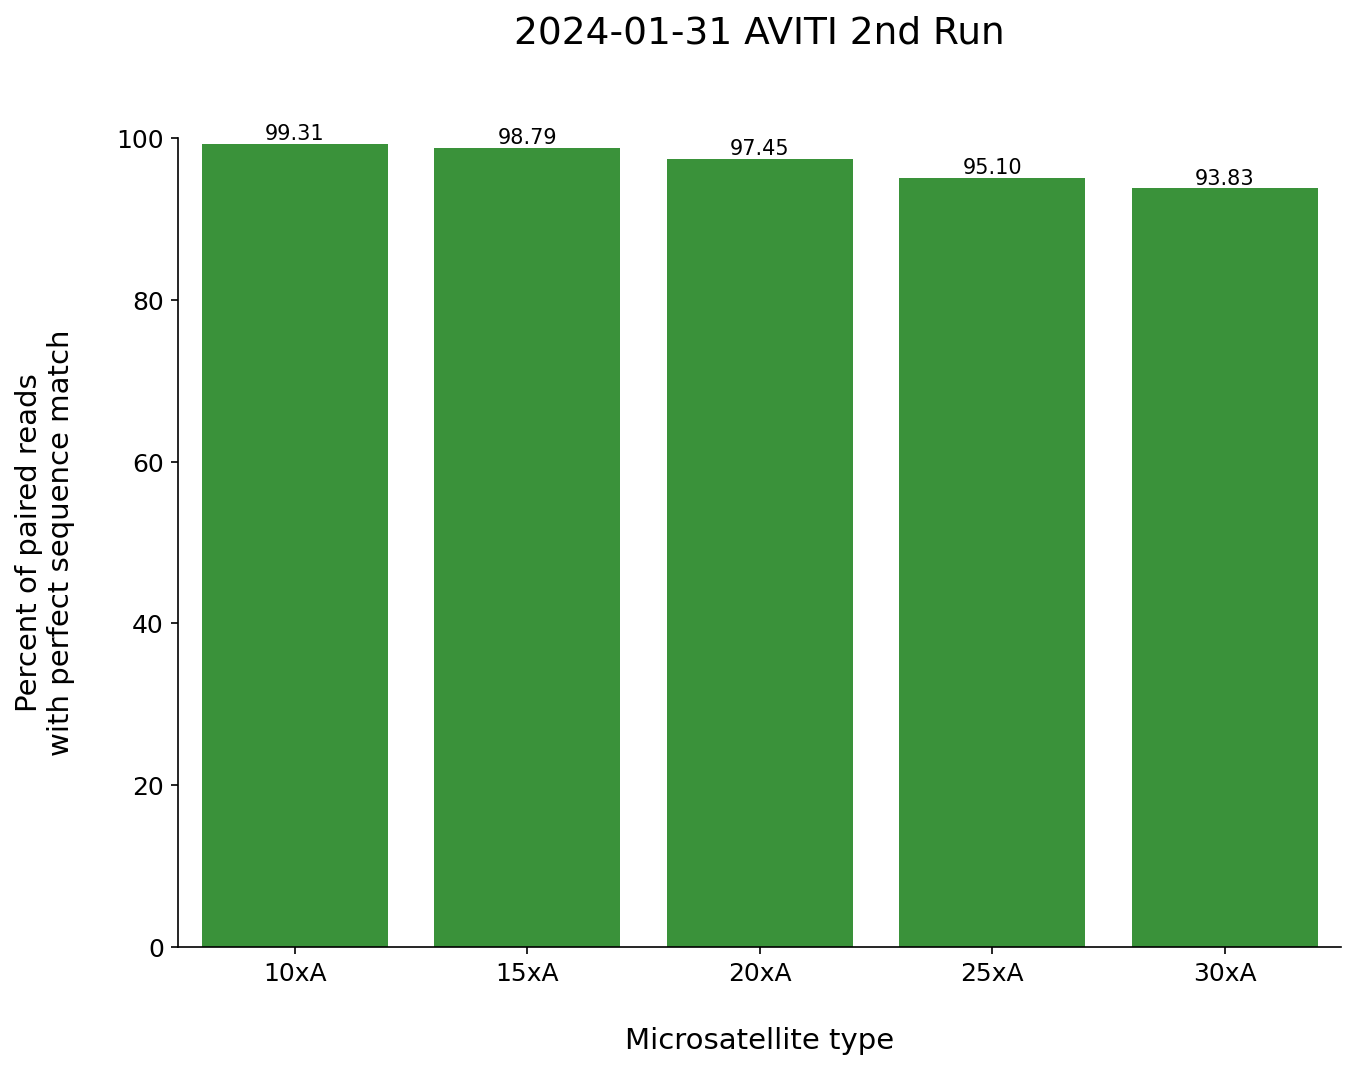

In [25]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=150)
ax = sns.barplot(x='lib_name', y='zero_diff_percent', data=grouped_percent, color='tab:green')

# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(0,100)

plt.title('2024-01-31 AVITI 2nd Run\n\n', fontsize=18)
plt.xlabel('\nMicrosatellite type', fontsize=14)
plt.ylabel('Percent of paired reads\nwith perfect sequence match\n', fontsize=14)

#ax.tick_params(axis='x', which='major', labelsize=20)
# Change x and y tick sizes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add the text on top of the bars
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2., p.get_height(), '{0:.2f}'.format(p.get_height()), 
            fontsize=10, color='black', ha='center', va='bottom')

plt.show()

## Add comparison plot for NextSeq 2000
- Run through the same script to get result for Illumina NextSeq 2000 (20231009 Library), I will manually add the result here

In [26]:
# Element Bio AVITI (20240216 Library)
grouped_percent['sequencer'] = ['Element Bio AVITI']*grouped_percent.shape[0]
grouped_percent

,lib_name,zero_diff_percent,sequencer
0,10xA,99.313264,Element Bio AVITI
1,15xA,98.794814,Element Bio AVITI
2,20xA,97.451268,Element Bio AVITI
3,25xA,95.099892,Element Bio AVITI
4,30xA,93.830276,Element Bio AVITI


In [27]:
# Illumina NextSeq 2000 (20231009 Library)
grouped_percent_nextseq = pd.DataFrame({'lib_name': ['10xA', '15xA', '20xA', '25xA', '30xA'],
                                      'zero_diff_percent': [97.762567, 96.759434, 83.438154, 81.299031, 55.691256],
                                      'sequencer': ['Illumina NextSeq 2000']*5})
grouped_percent_nextseq

,lib_name,zero_diff_percent,sequencer
0,10xA,97.762567,Illumina NextSeq 2000
1,15xA,96.759434,Illumina NextSeq 2000
2,20xA,83.438154,Illumina NextSeq 2000
3,25xA,81.299031,Illumina NextSeq 2000
4,30xA,55.691256,Illumina NextSeq 2000


In [28]:
grouped_percent_combined = pd.concat([grouped_percent_nextseq, grouped_percent])
grouped_percent_combined

,lib_name,zero_diff_percent,sequencer
0,10xA,97.762567,Illumina NextSeq 2000
1,15xA,96.759434,Illumina NextSeq 2000
2,20xA,83.438154,Illumina NextSeq 2000
3,25xA,81.299031,Illumina NextSeq 2000
4,30xA,55.691256,Illumina NextSeq 2000
0,10xA,99.313264,Element Bio AVITI
1,15xA,98.794814,Element Bio AVITI
2,20xA,97.451268,Element Bio AVITI
3,25xA,95.099892,Element Bio AVITI
4,30xA,93.830276,Element Bio AVITI


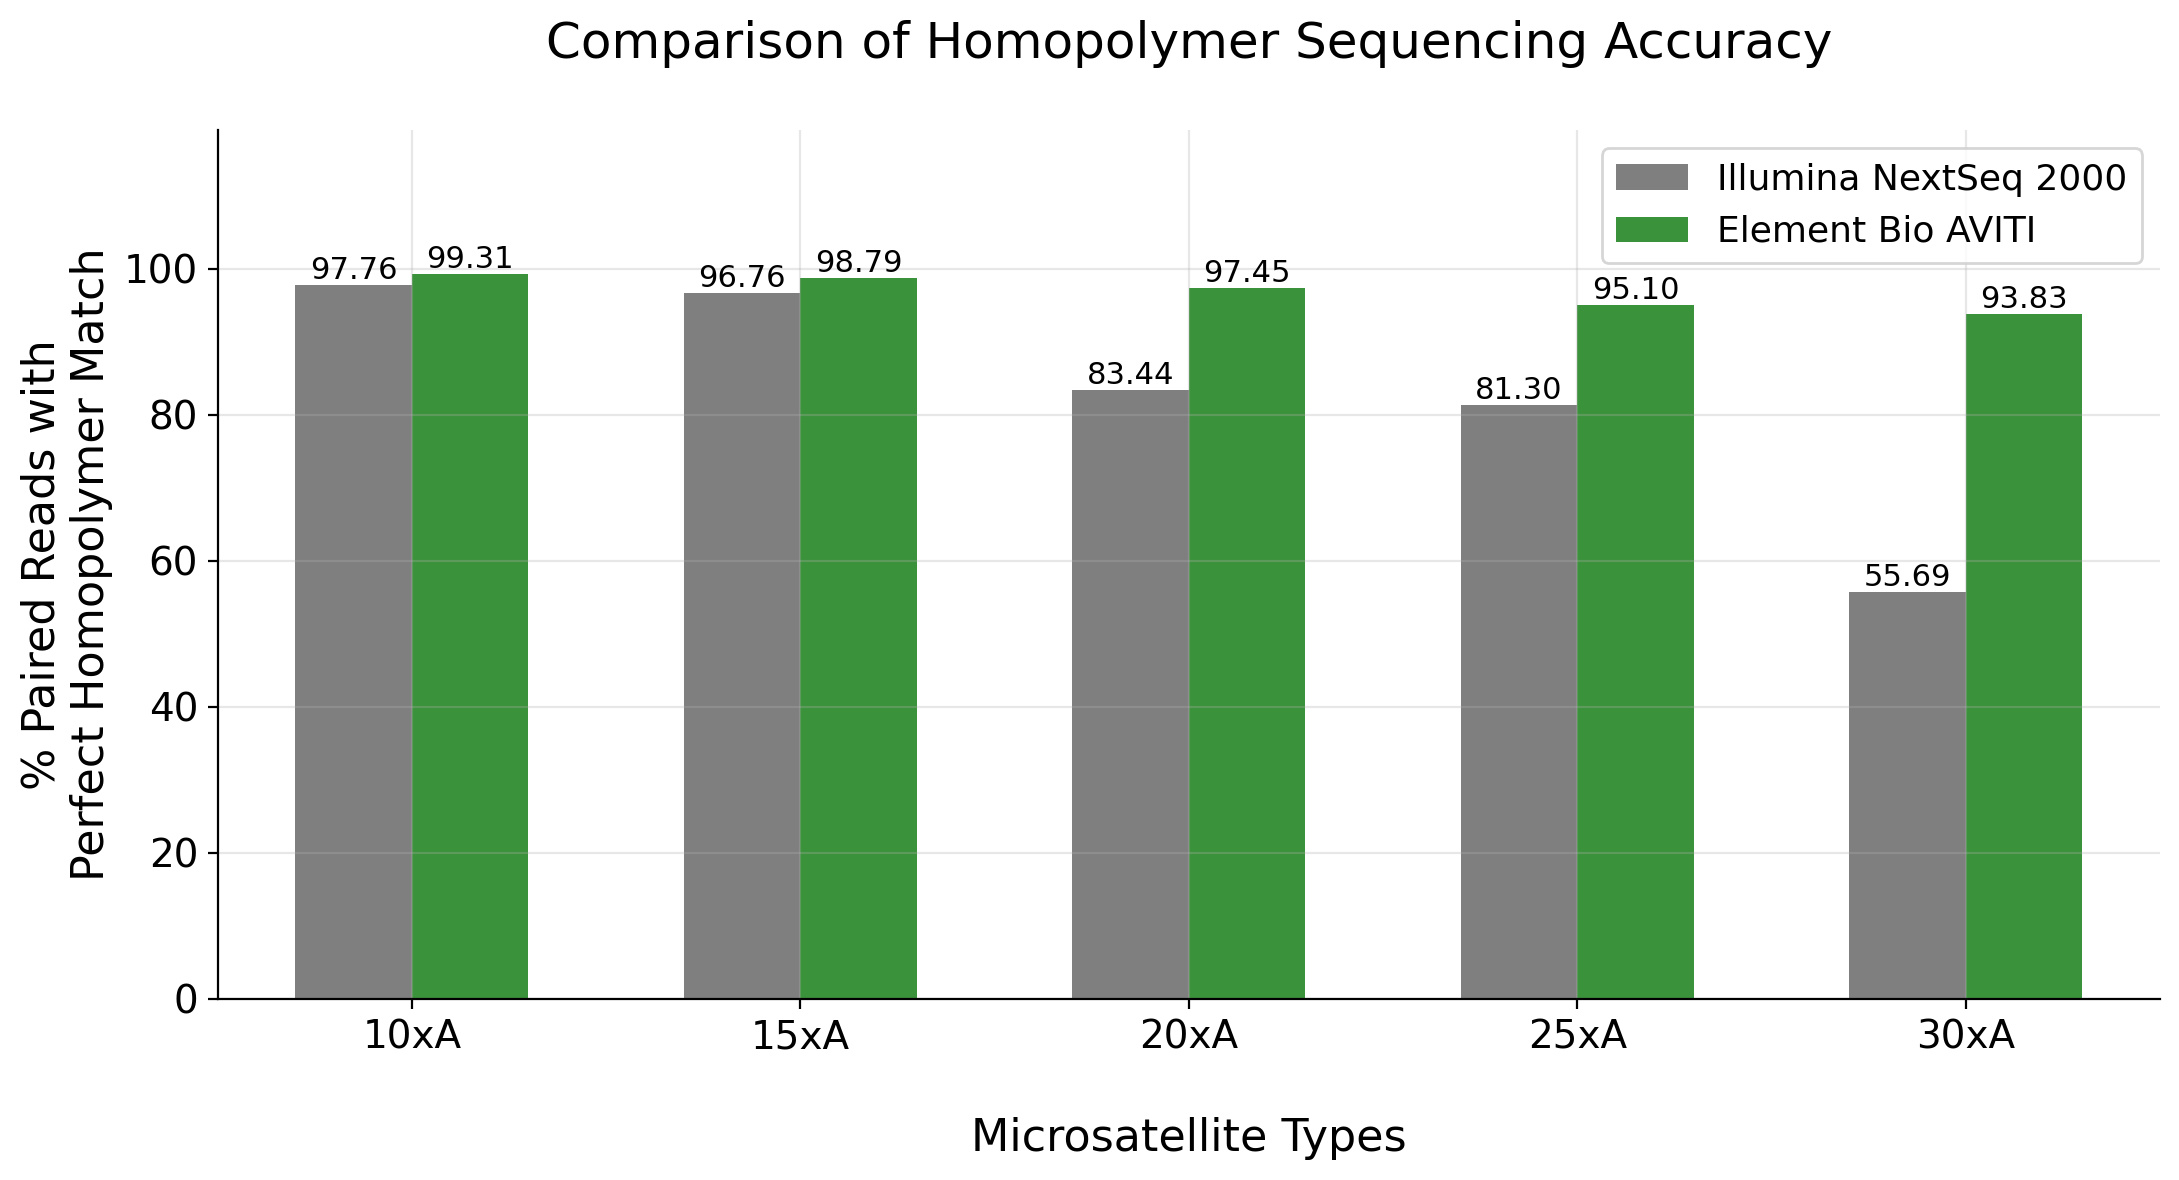

In [29]:
fig, ax = plt.subplots(figsize=(11, 6), dpi=200)
ax = sns.barplot(x='lib_name', y='zero_diff_percent', data=grouped_percent_combined, hue='sequencer',
                 order=['10xA', '15xA', '20xA', '25xA', '30xA'], width=0.6, palette=['tab:gray', 'tab:green'])

ax.grid(True, axis='both', alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(0,119)

plt.title('Comparison of Homopolymer Sequencing Accuracy\n', fontsize=18)
plt.xlabel('\nMicrosatellite Types', fontsize=16)
plt.ylabel('% Paired Reads with\nPerfect Homopolymer Match', fontsize=16)

# Change x and y tick sizes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Add the text on top of all the bars, excluding those with zero height
for p in ax.patches:
    if p.get_height() > 0:  # Check if the bar has a height greater than zero
        ax.text(p.get_x() + p.get_width() / 2., p.get_height(), '{0:.2f}'.format(p.get_height()), 
                fontsize=11, color='black', ha='center', va='bottom')

ax.legend(title='', loc='upper right', fontsize=13) 

plt.tight_layout()
plt.show()


## Line plot

In [30]:
# add n repeat column as integer type for line plot
grouped_percent_combined['n_repeat'] = [int(name.rstrip('xA')) for name in grouped_percent_combined['lib_name']]

In [31]:
grouped_percent_combined.head(10)

,lib_name,zero_diff_percent,sequencer,n_repeat
0,10xA,97.762567,Illumina NextSeq 2000,10
1,15xA,96.759434,Illumina NextSeq 2000,15
2,20xA,83.438154,Illumina NextSeq 2000,20
3,25xA,81.299031,Illumina NextSeq 2000,25
4,30xA,55.691256,Illumina NextSeq 2000,30
0,10xA,99.313264,Element Bio AVITI,10
1,15xA,98.794814,Element Bio AVITI,15
2,20xA,97.451268,Element Bio AVITI,20
3,25xA,95.099892,Element Bio AVITI,25
4,30xA,93.830276,Element Bio AVITI,30


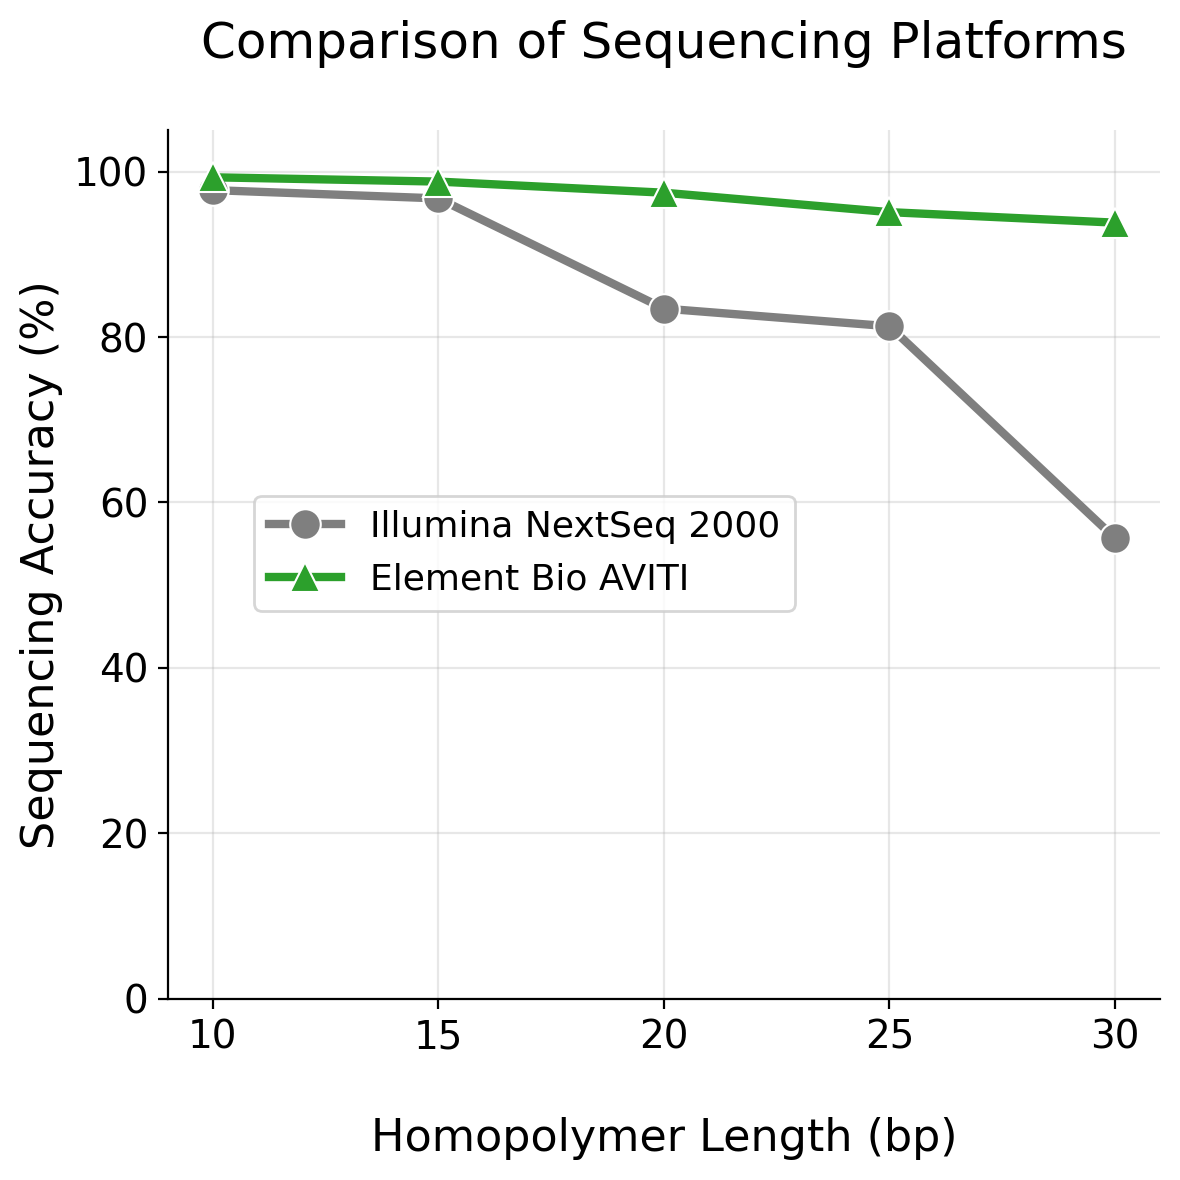

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

# Create line plot
ax = sns.lineplot(x='n_repeat', y='zero_diff_percent', data=grouped_percent_combined, hue='sequencer',
                  style='sequencer', markers=['o', '^'], dashes=False, palette=['tab:gray', 'tab:green'],
                  linewidth=3, markersize=11)

ax.grid(True, axis='both', alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(0, 105)
ax.set_xticks([10, 15, 20, 25, 30])

plt.title('Comparison of Sequencing Platforms\n', fontsize=18)
plt.xlabel('\nHomopolymer Length (bp)', fontsize=16)
plt.ylabel('Sequencing Accuracy (%)', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

ax.legend(title='', fontsize=13, bbox_to_anchor=(0.65, 0.6))

plt.tight_layout()
plt.savefig('Comparison_of_Sequencing_Platforms.pdf')
plt.show()